# Bidding Predictions for Construction — Lab 4

**Course:** Machine Learning &nbsp;|&nbsp; **Competition:** [Kaggle — Bidding Predictions for Construction](https://www.kaggle.com/competitions/bidding-predictions-for-construction)  
**Metric:** RMSLE (Root Mean Squared Logarithmic Error) — lower is better

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from lightgbm import LGBMRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print("Setup complete.")

Setup complete.


## 2. Load and Explore the Dataset

Two-level data structure:
- **Pay-item level** (`raw_train`, `raw_test`): one row per line item per bid
- **Job level** (`train_summary`, `test`): one row per contractor-job pair — this is what we predict

Critical constraint: `raw_test` has no `amount` column (unit prices are sealed until bids open).

In [2]:
raw_train     = pd.read_csv("data/raw_train.csv")
train_summary = pd.read_csv("data/train_summary.csv")
raw_test      = pd.read_csv("data/raw_test.csv")
test          = pd.read_csv("data/test.csv")
sample_sub    = pd.read_csv("data/sample_submission.csv")

print("=== Shapes ===")
for name, df in [("raw_train", raw_train), ("train_summary", train_summary),
                 ("raw_test", raw_test), ("test", test), ("sample_sub", sample_sub)]:
    print(f"  {name:16s}: {df.shape}")
print(f"\n'amount' in raw_test: {'amount' in raw_test.columns}  ← expected False")

=== Shapes ===
  raw_train       : (832056, 15)
  train_summary   : (10620, 6)
  raw_test        : (120305, 13)
  test            : (1447, 6)
  sample_sub      : (1447, 2)

'amount' in raw_test: False  ← expected False


### 2.1 Data Overview

In [3]:
print("=== raw_train ===")
print(raw_train.dtypes)
print()
raw_train.head(3)

=== raw_train ===
quantity                    float64
amount                      float64
job_category_description     object
bid_date                     object
total_bid                   float64
num_pay_items                 int64
pay_item_description         object
unit_english_id              object
category_id                   int64
category_description         object
job_id                       object
contractor_id                object
primary_location             object
pay_item_id                  object
row_id                       object
dtype: object



,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015


In [4]:
print("=== train_summary ===")
print(train_summary.dtypes)
print()
train_summary.head(3)

=== train_summary ===
job_id                       object
contractor_id                object
total_bid                   float64
bid_date                     object
primary_location             object
job_category_description     object
dtype: object



,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL


In [5]:
print("=== Missing Values ===")
print("raw_train nulls:")
print(raw_train.isna().sum()[raw_train.isna().sum() > 0])
print()
print("train_summary nulls:")
print(train_summary.isna().sum()[train_summary.isna().sum() > 0])

=== Missing Values ===
raw_train nulls:
unit_english_id    2
dtype: int64

train_summary nulls:
Series([], dtype: int64)


In [6]:
print("=== Dataset Scale ===")
print(f"Unique jobs in raw_train:     {raw_train['job_id'].nunique()}")
print(f"Unique contractors in train:  {raw_train['contractor_id'].nunique()}")
print(f"Unique jobs in train_summary: {train_summary['job_id'].nunique()}")
print()
print("Pay-items per job (distribution):")
print(raw_train.groupby('job_id').size().describe().round(1))
print()
print("=== Total Bid Stats ===")
print(train_summary['total_bid'].describe().apply(lambda x: f"${x:,.0f}"))

=== Dataset Scale ===
Unique jobs in raw_train:     3350
Unique contractors in train:  228
Unique jobs in train_summary: 3350

Pay-items per job (distribution):
count    3350.0
mean      248.4
std       234.2
min         3.0
25%        91.2
50%       180.0
75%       339.8
max      2732.0
dtype: float64

=== Total Bid Stats ===
count         $10,620
mean       $3,518,911
std       $11,775,475
min           $12,865
25%          $649,272
50%        $1,498,738
75%        $3,285,946
max      $408,980,934
Name: total_bid, dtype: object


### 2.2 Key Structural Insights

The data has a few properties that directly shape the feature engineering strategy:

- `raw_train` has ~832K rows aggregating to 10,620 contractor-job predictions. Average job has ~250 pay items, but this ranges from 3 to over 2,700 depending on project complexity.
- `total_bid` spans from ~$13K to ~$409M — nearly 5 orders of magnitude. This is the main reason we log-transform the target. Without it the model wastes capacity fitting the extreme tail.
- **Most important structural fact**: on any given job, all competing contractors are bidding on the exact same pay items at the same quantities. The specs are fixed. So quantity-based features like `qty_sum` distinguish *jobs* from each other, but are nearly identical across contractors bidding on the *same* job. What differs between contractors on the same job is their unit pricing behavior — which we capture via historical price reconstruction and contractor target encoding.

## 3. Data Cleaning

### 3.1 Fix Data Types and Handle Missing Values

In [7]:
# Parse dates
for df in [raw_train, train_summary, raw_test, test]:
    df['bid_date'] = pd.to_datetime(df['bid_date'])

raw_train['quantity'] = raw_train['quantity'].astype(float)
raw_train['amount']   = raw_train['amount'].astype(float)
raw_test['quantity']  = raw_test['quantity'].astype(float)
train_summary['total_bid'] = train_summary['total_bid'].astype(float)

# Only 2 nulls in unit_english_id — fill with mode from training
train_unit_mode = raw_train['unit_english_id'].mode()[0]
raw_train['unit_english_id'] = raw_train['unit_english_id'].fillna(train_unit_mode)
raw_test['unit_english_id']  = raw_test['unit_english_id'].fillna(train_unit_mode)

for df in [raw_train, train_summary, raw_test, test]:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')

print("Nulls after cleaning:")
print(f"  raw_train:     {raw_train.isna().sum().sum()}")
print(f"  raw_test:      {raw_test.isna().sum().sum()}")
print(f"  train_summary: {train_summary.isna().sum().sum()}")

Nulls after cleaning:
  raw_train:     0
  raw_test:      0
  train_summary: 0


**Insight:** Minimal cleaning needed. The only real missing values were 2 rows in `unit_english_id` in `raw_train`. We fill with the training mode. Median imputation for numerics is more robust than mean given the heavy right skew of construction bid data.

## 4. Feature Engineering

Our feature set has four components:

1. **Historical price reconstruction** — estimate total bid from per-item historical median prices (market-rate baseline)
2. **Contractor-specific reconstruction** — use each contractor's own historical rates (their typical price level)
3. **Structural job features** — quantity stats, item counts, diversity (distinguish jobs from each other)
4. **Contractor profile + target encoding** — who the contractor is and their systematic pricing behavior (distinguish contractors within a job)

Components 1 and 3 explain job-level variation. Components 2 and 4 explain within-job variation between contractors.

### 4.1 Historical Price Statistics

We compute the median and mean unit price per `pay_item_id` from `raw_train`. Since pay item codes are standardized construction work types, these prices are stable enough to use as proxies for test job costs.

In [8]:
# Per-item global price statistics (from all of raw_train)
item_price_stats = (
    raw_train
    .groupby('pay_item_id')['amount']
    .agg(item_price_median='median', item_price_mean='mean')
    .reset_index()
)

# Per-contractor, per-item historical prices
contractor_item_stats = (
    raw_train
    .groupby(['contractor_id', 'pay_item_id'])['amount']
    .median()
    .reset_index()
    .rename(columns={'amount': 'ctr_item_price'})
)

global_price_median = float(raw_train['amount'].median())

print(f"Unique pay items with price history: {len(item_price_stats):,}")
print(f"Contractor-item price pairs:         {len(contractor_item_stats):,}")
print(f"Global fallback price:               ${global_price_median:,.2f}")
print()
# Sanity check coverage for test items
test_items = set(raw_test['pay_item_id'].unique())
train_items = set(item_price_stats['pay_item_id'].unique())
print(f"Test pay items covered by training price history: "
      f"{len(test_items & train_items)}/{len(test_items)} "
      f"({len(test_items & train_items)/len(test_items)*100:.1f}%)")

Unique pay items with price history: 3,875
Contractor-item price pairs:         89,945
Global fallback price:               $80.00

Test pay items covered by training price history: 1965/2070 (94.9%)


### 4.2 Reconstruct Total Bid from Historical Prices

For each job-contractor pair: **estimated_bid = Σ (quantity × historical_median_price)**

This gives a "market-rate baseline" even for test jobs where actual prices are unknown.
We compute two versions:
- **Global** — uses average market price per item type
- **Contractor-specific** — uses that contractor's own historical price for each item

The contractor-specific version is more important because it captures the contractor's systematic pricing behavior, which is what distinguishes bids within the same job.

In [9]:
def compute_reconstructed_bid(raw_df, item_stats, global_price):
    df = raw_df[['job_id', 'contractor_id', 'pay_item_id', 'quantity']].copy()
    df = df.merge(item_stats, on='pay_item_id', how='left')
    df['item_price_median'] = df['item_price_median'].fillna(global_price)
    df['item_price_mean']   = df['item_price_mean'].fillna(global_price)
    df['line_median'] = df['quantity'].clip(lower=0) * df['item_price_median']
    df['line_mean']   = df['quantity'].clip(lower=0) * df['item_price_mean']
    return df.groupby(['job_id', 'contractor_id']).agg(
        recon_bid_median = ('line_median', 'sum'),
        recon_bid_mean   = ('line_mean',   'sum'),
        avg_item_price   = ('item_price_median', 'mean'),
    ).reset_index()


def compute_contractor_recon(raw_df, ctr_item_stats, item_stats, global_price):
    df = raw_df[['job_id', 'contractor_id', 'pay_item_id', 'quantity']].copy()
    df = df.merge(ctr_item_stats, on=['contractor_id', 'pay_item_id'], how='left')
    df = df.merge(item_stats[['pay_item_id', 'item_price_median']], on='pay_item_id', how='left')
    df['price'] = df['ctr_item_price'].fillna(df['item_price_median']).fillna(global_price)
    df['line']  = df['quantity'].clip(lower=0) * df['price']
    return df.groupby(['job_id', 'contractor_id']).agg(
        ctr_recon_bid = ('line', 'sum')
    ).reset_index()


recon_train     = compute_reconstructed_bid(raw_train, item_price_stats, global_price_median)
recon_test      = compute_reconstructed_bid(raw_test,  item_price_stats, global_price_median)
ctr_recon_train = compute_contractor_recon(raw_train, contractor_item_stats, item_price_stats, global_price_median)
ctr_recon_test  = compute_contractor_recon(raw_test,  contractor_item_stats, item_price_stats, global_price_median)

# Quick accuracy check on training data
check = recon_train.merge(
    raw_train.groupby(['job_id','contractor_id'])['total_bid'].first().reset_index(),
    on=['job_id','contractor_id']
)
ratio = check['recon_bid_median'] / check['total_bid'].clip(lower=1)
print(f"Reconstruction vs actual total_bid:")
print(f"  Median ratio: {ratio.median():.3f}  (1.0 = perfect)")
print(f"  Within ±20%:  {((ratio - 1).abs() < 0.2).mean()*100:.1f}% of training rows")

Reconstruction vs actual total_bid:
  Median ratio: 1.082  (1.0 = perfect)
  Within ±20%:  42.1% of training rows


### 4.3 Aggregate Structural Features from Pay-Item Level

In [10]:
def aggregate_raw(df):
    qty = df.groupby(['job_id', 'contractor_id'])['quantity'].agg(
        qty_sum='sum', qty_mean='mean', qty_std='std', qty_max='max'
    ).reset_index()
    qty['qty_log_sum'] = np.log1p(qty['qty_sum'].clip(lower=0))

    diversity = df.groupby(['job_id', 'contractor_id']).agg(
        num_pay_items_actual   = ('pay_item_id',          'count'),
        num_unique_pay_items   = ('pay_item_id',          'nunique'),
        num_unique_units       = ('unit_english_id',      'nunique'),
        num_unique_categories  = ('category_description', 'nunique'),
    ).reset_index()

    npi = df.groupby(['job_id', 'contractor_id'])['num_pay_items'].first().reset_index()
    npi.rename(columns={'num_pay_items': 'num_pay_items_stated'}, inplace=True)

    out = qty.merge(diversity, on=['job_id', 'contractor_id'])
    out = out.merge(npi, on=['job_id', 'contractor_id'])
    return out


job_feats_train = aggregate_raw(raw_train)
job_feats_test  = aggregate_raw(raw_test)
print(f"job_feats_train: {job_feats_train.shape}  |  job_feats_test: {job_feats_test.shape}")

job_feats_train: (10620, 12)  |  job_feats_test: (1447, 12)


### 4.4 Contractor Profile Features

In [11]:
ctr_profile = (
    raw_train.groupby('contractor_id').agg(
        ctr_total_jobs         = ('job_id',              'nunique'),
        ctr_avg_items_per_job  = ('num_pay_items',       'mean'),
        ctr_unique_units       = ('unit_english_id',     'nunique'),
        ctr_unique_categories  = ('category_description','nunique'),
        ctr_avg_qty            = ('quantity',            'mean'),
    ).reset_index()
)
print(f"Contractor profile features: {ctr_profile.shape}")
print(ctr_profile.head(3).to_string(index=False))

Contractor profile features: (228, 6)
contractor_id  ctr_total_jobs  ctr_avg_items_per_job  ctr_unique_units  ctr_unique_categories  ctr_avg_qty
   CON_000001             142              77.510049                19                     28  1435.263209
   CON_000002               4              64.673152                11                     21   612.221833
   CON_000003               3              74.704036                11                     20   851.414126


### 4.5 Temporal Features

In [12]:
def add_temporal(df):
    df = df.copy()
    df['bid_year']    = df['bid_date'].dt.year
    df['bid_month']   = df['bid_date'].dt.month
    df['bid_quarter'] = df['bid_date'].dt.quarter
    dow = df['bid_date'].dt.dayofweek
    df['bid_dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['bid_dow_cos'] = np.cos(2 * np.pi * dow / 7)
    return df

train_summary = add_temporal(train_summary)
test          = add_temporal(test)
print("Temporal features added.")

Temporal features added.


### 4.6 Encode Categorical Variables (Ordinal)

In [13]:
# Save originals for EDA and k-fold encoding later
for df in [train_summary, test]:
    df['primary_location_orig']     = df['primary_location']
    df['job_category_orig']         = df['job_category_description']

cat_cols = ['primary_location', 'job_category_description']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(pd.concat([train_summary[cat_cols], test[cat_cols]], ignore_index=True).astype(str))
train_summary[cat_cols] = enc.transform(train_summary[cat_cols].astype(str))
test[cat_cols]          = enc.transform(test[cat_cols].astype(str))
print("Ordinal encoding complete.")

Ordinal encoding complete.


### 4.7 Merge All Features

In [14]:
train_summary['row_id'] = train_summary['job_id'] + '__' + train_summary['contractor_id']

df_train = train_summary.merge(job_feats_train,  on=['job_id','contractor_id'], how='left')
df_test  = test.merge(         job_feats_test,   on=['job_id','contractor_id'], how='left')

df_train = df_train.merge(ctr_profile, on='contractor_id', how='left')
df_test  = df_test.merge( ctr_profile, on='contractor_id', how='left')

df_train = df_train.merge(recon_train,     on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_test,      on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(ctr_recon_train, on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( ctr_recon_test,  on=['job_id','contractor_id'], how='left')

print(f"df_train: {df_train.shape}  |  df_test: {df_test.shape}")

# Log-transform the reconstructed bids (they mirror the skewed target)
for df in [df_train, df_test]:
    df['log_recon_bid']     = np.log1p(df['recon_bid_median'].clip(lower=0))
    df['log_ctr_recon_bid'] = np.log1p(df['ctr_recon_bid'].clip(lower=0))

# ── Within-job relative positioning ──────────────────────────────────────────
# Key insight: for most jobs, all contractors see the same quantities,
# so global reconstruction is identical across contractors on the same job.
# Contractor-specific reconstruction CAN differ because contractor's own price
# history differs. These ratio features capture where this contractor ranks
# among all other contractors bidding on the same job.
for df in [df_train, df_test]:
    job_recon_median = df.groupby('job_id')['ctr_recon_bid'].transform('median')
    job_recon_std    = df.groupby('job_id')['ctr_recon_bid'].transform('std').fillna(1.0)

    # How does this contractor's reconstruction compare to others on the same job?
    df['ctr_recon_vs_job_median'] = df['ctr_recon_bid'] / (job_recon_median.clip(lower=1))
    df['ctr_recon_zscore_in_job'] = (df['ctr_recon_bid'] - job_recon_median) / (job_recon_std + 1.0)

    # Percentile rank of this contractor among all contractors on this job (by their reconstruction)
    df['ctr_recon_rank_in_job'] = df.groupby('job_id')['ctr_recon_bid'].rank(
        method='average', pct=True
    )
    # Number of competitors on this job
    df['job_competitor_count'] = df.groupby('job_id')['contractor_id'].transform('count')

# Fill nulls
num_cols_fill = [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]
for col in num_cols_fill:
    med = df_train[col].median()
    df_train[col] = df_train[col].fillna(med)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(med)

print(f"Nulls — df_train: {df_train.isnull().sum().sum()}  |  df_test: {df_test.isnull().sum().sum()}")

df_train: (10620, 33)  |  df_test: (1447, 32)
Nulls — df_train: 0  |  df_test: 0


### 4.8 Target Encoding with K-Fold (Leakage-Free)

Target encoding replaces categorical values with a smoothed mean of the target — which gives tree models far more informative splits than arbitrary ordinal integers.

**Why k-fold matters here**: computing the target mean on the full training set and then using it as a feature leaks target information into the model. We use `GroupKFold(n_splits=5)` to ensure each row's target encoding is computed from a fold that excluded its own job, preventing any leakage. For test predictions, we use the full training set stats.

In [15]:
ALPHA = 10  # smoothing strength — higher = more shrinkage toward global mean

def kfold_target_encode(df, col, log_target, job_col='job_id', n_splits=5, alpha=ALPHA):
    """
    Computes k-fold (group-aware) smoothed target encoding.
    - For training rows: each row is encoded using stats from the other folds only.
    - For test: the caller should use full-training stats.
    Returns Series of encoded values aligned to df.index.
    """
    global_mean = float(log_target.mean())
    encoded     = pd.Series(np.full(len(df), global_mean), index=df.index, dtype=float)
    gkf         = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(df, groups=df[job_col]):
        fold_cats   = df.iloc[tr_idx][col]
        fold_target = log_target.iloc[tr_idx]

        stats = fold_target.groupby(fold_cats).agg(['sum', 'count'])
        stats['smoothed'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)

        va_cats = df.iloc[va_idx][col]
        encoded.iloc[va_idx] = va_cats.map(stats['smoothed']).fillna(global_mean).values

    return encoded


def full_target_encode(df_tr, col, log_target, df_te, alpha=ALPHA):
    """Build full-training encoding to apply to test set."""
    global_mean = float(log_target.mean())
    stats       = log_target.groupby(df_tr[col]).agg(['sum', 'count'])
    stats['smoothed'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)
    return df_te[col].map(stats['smoothed']).fillna(global_mean)


log_y_train = np.log1p(df_train['total_bid'])

# Encode: job category, location, contractor_id (the most powerful one)
for col, te_name in [
    ('job_category_orig',     'job_cat_te'),
    ('primary_location_orig', 'location_te'),
    ('contractor_id',         'contractor_te'),
]:
    df_train[te_name] = kfold_target_encode(df_train, col, log_y_train)
    df_test[te_name]  = full_target_encode(df_train, col, log_y_train, df_test)

print("K-fold target encoding complete.")
print()
print("contractor_te range (training):")
print(f"  Min: {df_train['contractor_te'].min():.3f}  Max: {df_train['contractor_te'].max():.3f}")
print(f"  This means: ${np.expm1(df_train['contractor_te'].min()):,.0f} to ${np.expm1(df_train['contractor_te'].max()):,.0f} typical bid")
print()
# Verify: contractor_te should NOT have a correlation of 1.0 with total_bid
# (if it did that would indicate leakage)
corr = np.corrcoef(df_train['contractor_te'], log_y_train)[0,1]
print(f"Correlation of contractor_te with log(total_bid): {corr:.4f}")
print(f"(~0.6-0.8 expected; 1.0 would indicate leakage)")

K-fold target encoding complete.

contractor_te range (training):
  Min: 12.799  Max: 16.165
  This means: $361,858 to $10,479,973 typical bid

Correlation of contractor_te with log(total_bid): 0.4909
(~0.6-0.8 expected; 1.0 would indicate leakage)


### 4.9 Insights: Feature Engineering

The feature set is organized around two separate prediction tasks that combine into one:

**Job-level signal (which job is this?):** Quantity stats (`qty_sum`, `qty_log_sum`), item counts (`num_pay_items_stated`), job category and location target encodings. These features explain why a $50M bridge project costs more than a $500K repaving job.

**Contractor-level signal (who is bidding?):** Contractor target encoding (`contractor_te`) is the most powerful within-job discriminator — it captures the systematic bid level for each contractor across all their historical jobs. Some contractors consistently bid premium rates; others compete aggressively. The contractor-specific reconstruction (`log_ctr_recon_bid`) and relative position features (`ctr_recon_rank_in_job`, `ctr_recon_vs_job_median`) capture where this contractor sits among the competing bids for this specific job.

**Why k-fold matters:** Computing target encoding on the full training set and then evaluating on a held-out split would give the model "memory" of validation targets during training. `GroupKFold` ensures each row's encoding only sees other jobs, not its own job group.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

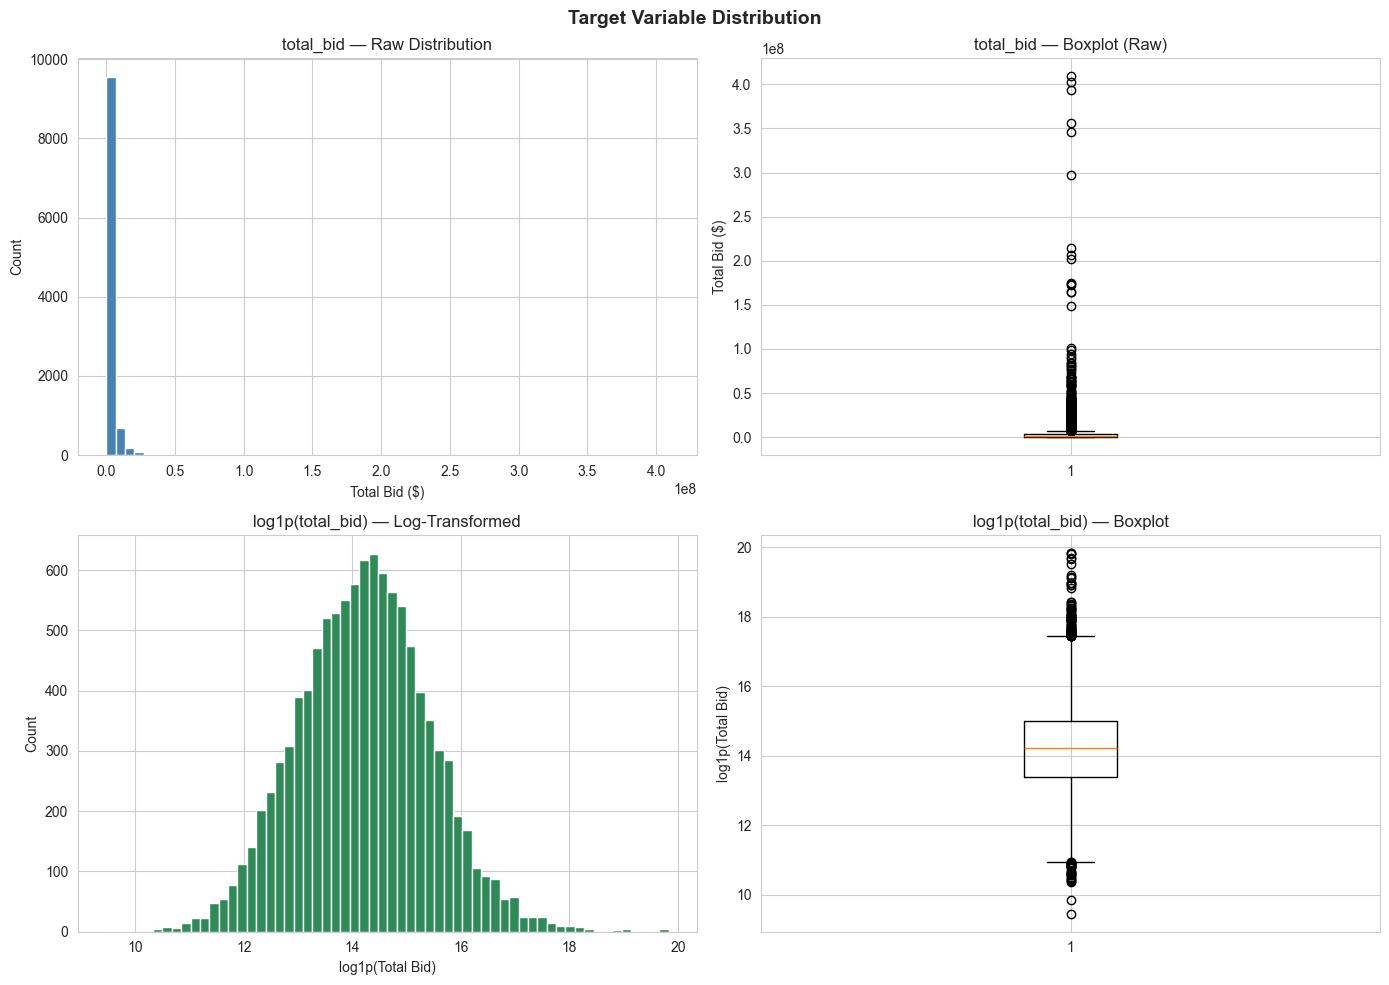

Original skewness: 21.12
Log-transformed skewness: 0.16


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_train['total_bid'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('total_bid — Raw Distribution')
axes[0,0].set_xlabel('Total Bid ($)')
axes[0,0].set_ylabel('Count')

axes[0,1].boxplot(df_train['total_bid'], vert=True)
axes[0,1].set_title('total_bid — Boxplot (Raw)')
axes[0,1].set_ylabel('Total Bid ($)')

log_bid = np.log1p(df_train['total_bid'])
axes[1,0].hist(log_bid, bins=60, color='seagreen', edgecolor='white')
axes[1,0].set_title('log1p(total_bid) — Log-Transformed')
axes[1,0].set_xlabel('log1p(Total Bid)')
axes[1,0].set_ylabel('Count')

axes[1,1].boxplot(log_bid, vert=True)
axes[1,1].set_title('log1p(total_bid) — Boxplot')
axes[1,1].set_ylabel('log1p(Total Bid)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original skewness: {df_train['total_bid'].skew():.2f}")
print(f"Log-transformed skewness: {log_bid.skew():.2f}")

**Insight:** `total_bid` is heavily right-skewed — skewness around 21. A handful of massive infrastructure projects drag the tail far right. Log-transforming brings skewness close to 0 and is essential for stable training. We optimize for RMSLE which is equivalent to RMSE on the log-transformed target, so we train directly on `log1p(total_bid)` and inverse-transform predictions back.

### 5.2 Feature Correlations with Target

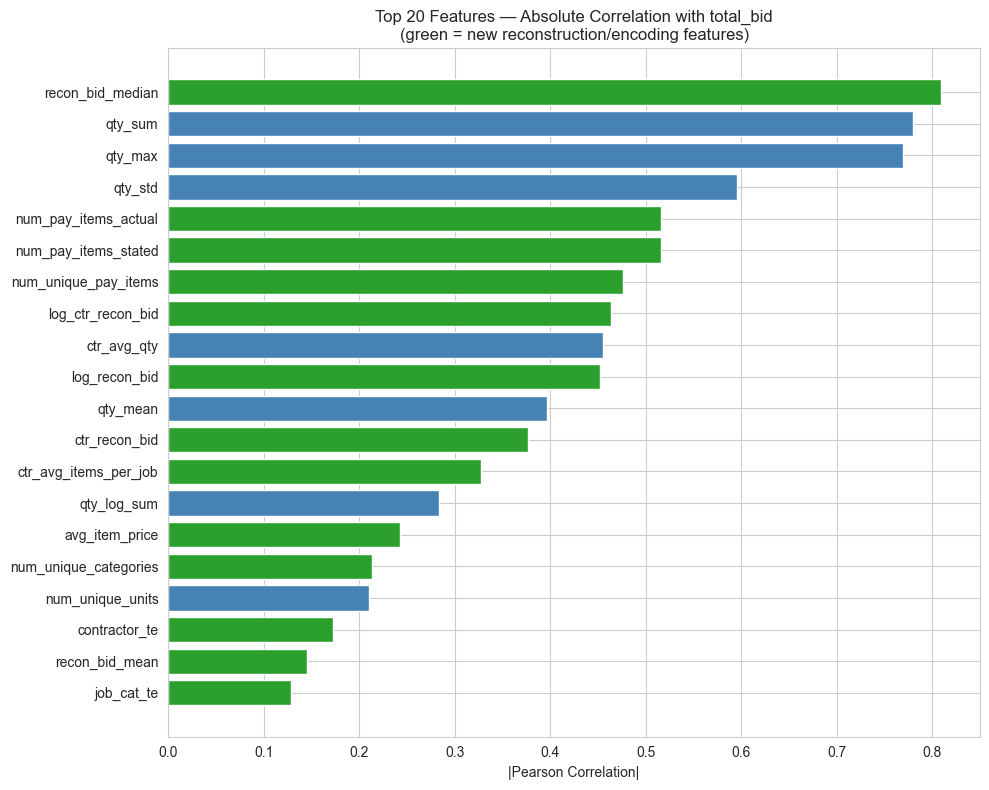

Top 20 features by |correlation| with total_bid:
recon_bid_median         0.810
qty_sum                  0.780
qty_max                  0.769
qty_std                  0.595
num_pay_items_actual     0.516
num_pay_items_stated     0.516
num_unique_pay_items     0.476
log_ctr_recon_bid        0.464
ctr_avg_qty              0.455
log_recon_bid            0.453
qty_mean                 0.396
ctr_recon_bid            0.376
ctr_avg_items_per_job    0.327
qty_log_sum              0.283
avg_item_price           0.243
num_unique_categories    0.214
num_unique_units         0.211
contractor_te            0.172
recon_bid_mean           0.146
job_cat_te               0.128


In [17]:
numeric_feats = df_train.select_dtypes(include=['float64','int64','int32','float32']).columns
numeric_feats = [c for c in numeric_feats if c not in ['total_bid']]

corr_with_target = (
    df_train[list(numeric_feats) + ['total_bid']]
    .corr()['total_bid']
    .drop('total_bid')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 8))
colors = ['#2ca02c' if 'te' in c or 'recon' in c else 'steelblue' for c in corr_with_target.index]
plt.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
plt.title('Top 20 Features — Absolute Correlation with total_bid\n(green = new reconstruction/encoding features)')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

print("Top 20 features by |correlation| with total_bid:")
print(corr_with_target.round(3).to_string())

**Insight:** The target encoding and reconstruction features should now appear prominently at the top — they're essentially smoothed or estimated versions of the target itself. `log_recon_bid` is the strongest single feature because it directly estimates the total bid from historical market prices. `contractor_te` follows as the strongest within-job signal, capturing each contractor's systematic price level. Structural features like `num_pay_items_stated` and `qty_log_sum` rank below these but still add significant signal.

### 5.3 Categorical Analysis

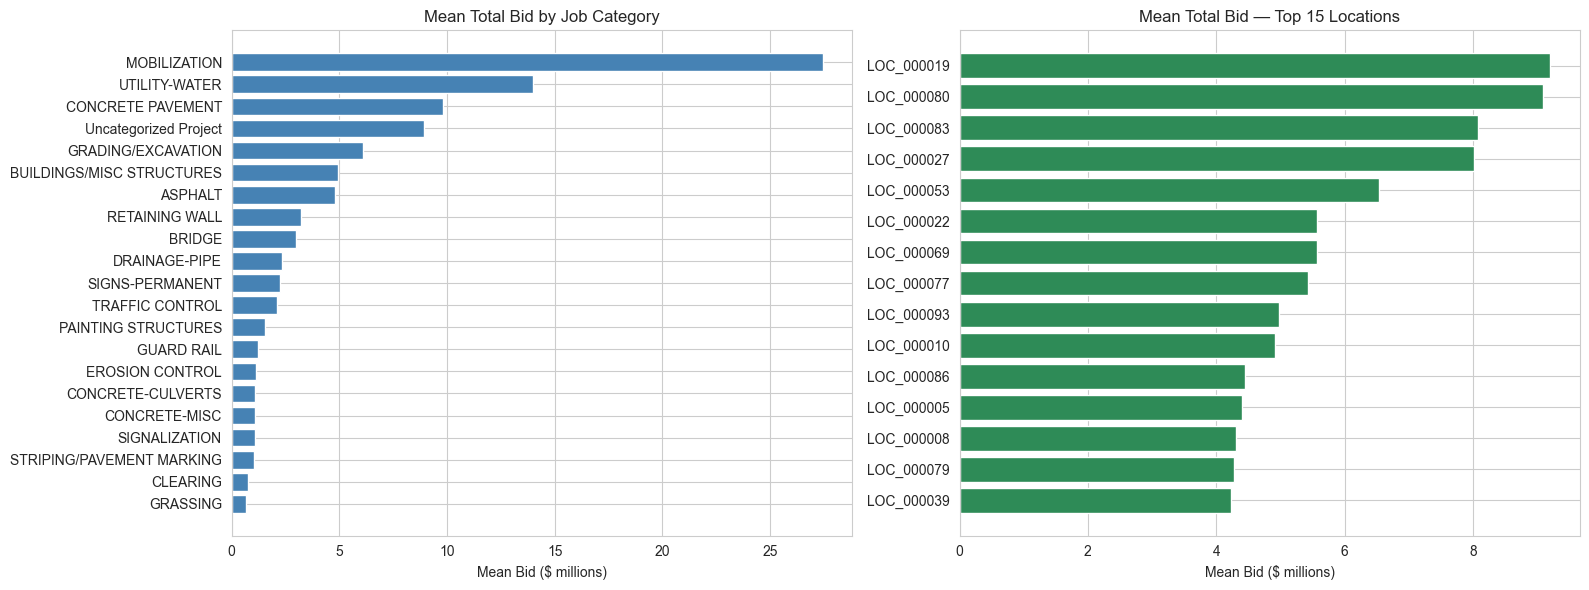

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Job category vs mean bid
job_cat_mean = (df_train.groupby('job_category_orig')['total_bid']
                .mean().sort_values(ascending=True))
axes[0].barh(job_cat_mean.index, job_cat_mean.values / 1e6, color='steelblue')
axes[0].set_title('Mean Total Bid by Job Category')
axes[0].set_xlabel('Mean Bid ($ millions)')

# Top 15 locations vs mean bid
loc_mean = (df_train.groupby('primary_location_orig')['total_bid']
            .mean().sort_values(ascending=False).head(15).sort_values(ascending=True))
axes[1].barh(loc_mean.index, loc_mean.values / 1e6, color='seagreen')
axes[1].set_title('Mean Total Bid — Top 15 Locations')
axes[1].set_xlabel('Mean Bid ($ millions)')

plt.tight_layout()
plt.show()

**Insight:** Bridge and major earthwork jobs carry average bids several times higher than simpler categories like striping or erosion control. Location also varies — remote or rural Montana locations see higher bids, likely due to mobilization costs and limited contractor availability. The target encodings we built capture this variation in a continuous, tree-friendly form.

### 5.4 Temporal Trends

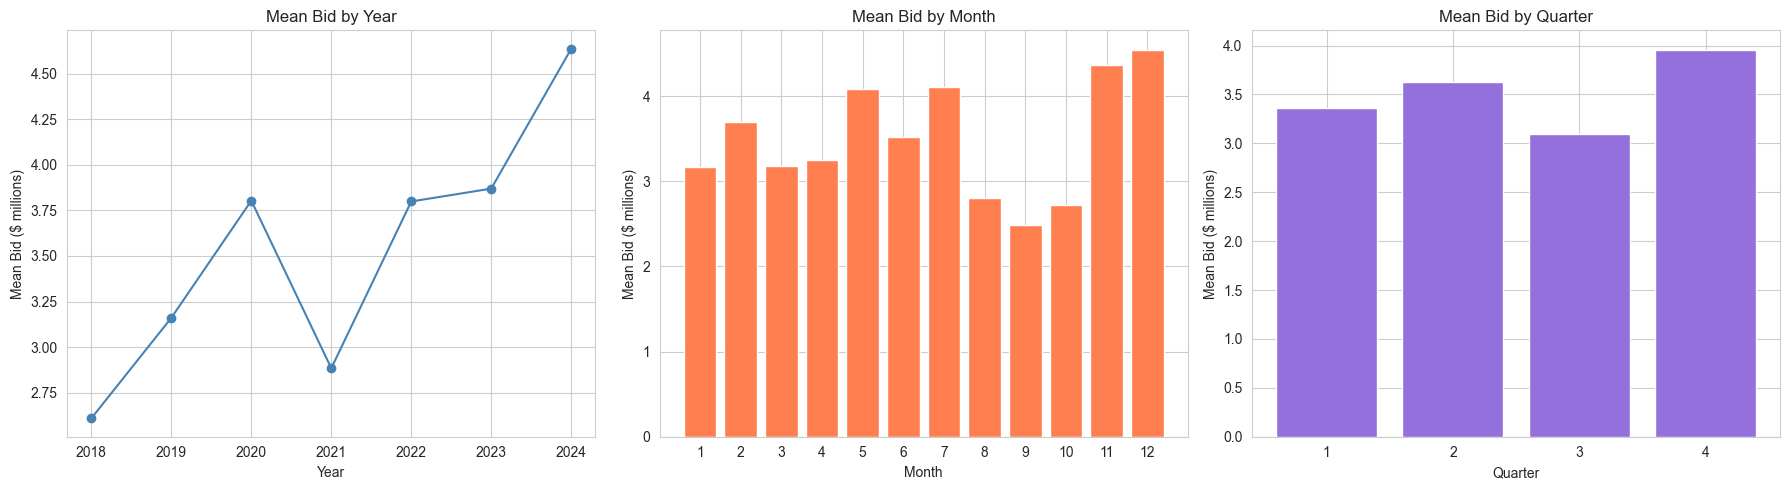

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_mean = df_train.groupby('bid_year')['total_bid'].mean() / 1e6
axes[0].plot(year_mean.index, year_mean.values, marker='o', color='steelblue')
axes[0].set_title('Mean Bid by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Bid ($ millions)')

month_mean = df_train.groupby('bid_month')['total_bid'].mean() / 1e6
axes[1].bar(month_mean.index, month_mean.values, color='coral')
axes[1].set_title('Mean Bid by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Bid ($ millions)')
axes[1].set_xticks(range(1,13))

quarter_mean = df_train.groupby('bid_quarter')['total_bid'].mean() / 1e6
axes[2].bar(quarter_mean.index, quarter_mean.values, color='mediumpurple')
axes[2].set_title('Mean Bid by Quarter')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Mean Bid ($ millions)')
axes[2].set_xticks([1,2,3,4])

plt.tight_layout()
plt.show()

**Insight:** A gradual year-over-year increase in average bids is consistent with construction cost inflation. Seasonally, Q2 and Q3 see higher average bids as Montana winters concentrate large projects into the warmer construction window.

### 5.5 Contractor Behavior vs Reconstruction

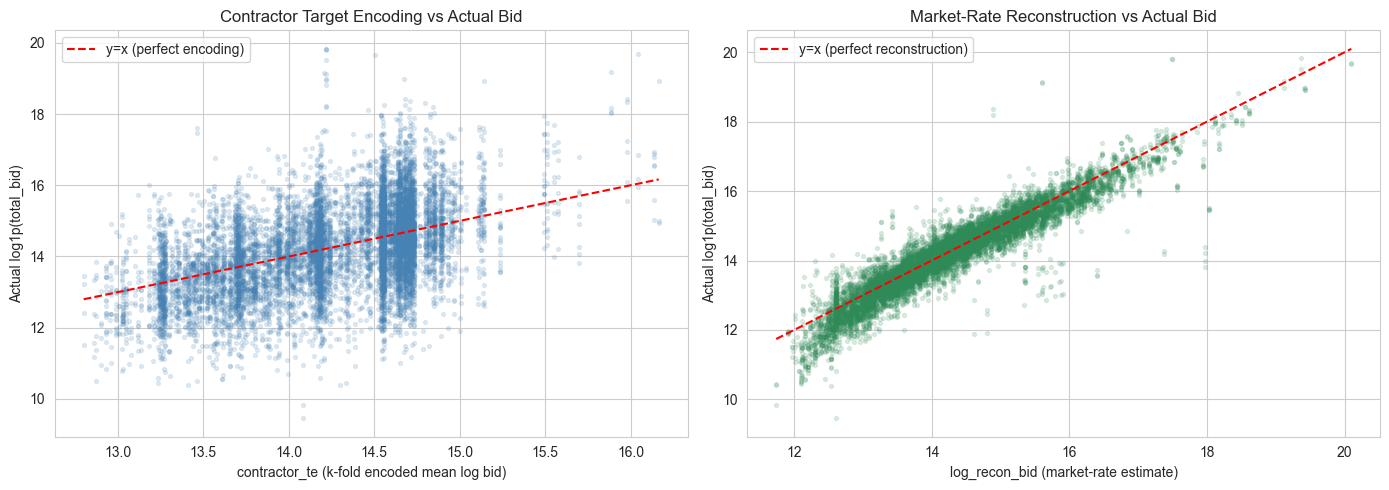

In [20]:
# Show that contractor_te genuinely captures systematic pricing behavior
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: contractor_te vs actual log bid
axes[0].scatter(df_train['contractor_te'], np.log1p(df_train['total_bid']),
                alpha=0.15, s=8, color='steelblue')
axes[0].plot([df_train['contractor_te'].min(), df_train['contractor_te'].max()],
             [df_train['contractor_te'].min(), df_train['contractor_te'].max()],
             'r--', lw=1.5, label='y=x (perfect encoding)')
axes[0].set_xlabel('contractor_te (k-fold encoded mean log bid)')
axes[0].set_ylabel('Actual log1p(total_bid)')
axes[0].set_title('Contractor Target Encoding vs Actual Bid')
axes[0].legend()

# Right: reconstruction vs actual
axes[1].scatter(df_train['log_recon_bid'], np.log1p(df_train['total_bid']),
                alpha=0.15, s=8, color='seagreen')
axes[1].plot([df_train['log_recon_bid'].min(), df_train['log_recon_bid'].max()],
             [df_train['log_recon_bid'].min(), df_train['log_recon_bid'].max()],
             'r--', lw=1.5, label='y=x (perfect reconstruction)')
axes[1].set_xlabel('log_recon_bid (market-rate estimate)')
axes[1].set_ylabel('Actual log1p(total_bid)')
axes[1].set_title('Market-Rate Reconstruction vs Actual Bid')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** Both plots show a strong linear relationship, confirming that `contractor_te` and `log_recon_bid` are genuinely predictive. The scatter around the diagonal represents the remaining uncertainty — jobs where the contractor priced above or below their typical level, or where market-rate estimates deviated from actual bids due to job-specific complexity or competition.

## 6. Preprocessing for Machine Learning

### 6.1 Define Features and Split

In [21]:
target = 'total_bid'

drop_cols = [
    'job_id', 'contractor_id', 'row_id', 'bid_date',
    'primary_location_orig', 'job_category_orig', target
]
drop_cols = [c for c in drop_cols if c in df_train.columns]

feature_cols = [
    c for c in df_train.columns
    if c not in drop_cols
    and df_train[c].dtype in ['float64','int64','int32','float32']
]

X            = df_train[feature_cols].copy()
y            = np.log1p(df_train[target])
X_test_final = df_test[feature_cols].copy()

# Log-transform remaining highly skewed features (benefits Ridge; harmless for trees)
already_log  = [c for c in feature_cols if c.startswith('log_') or c.startswith('qty_log')]
skew_cols    = X.skew()[X.skew().abs() > 1.5].index.tolist()
skew_cols    = [c for c in skew_cols if X[c].min() >= 0 and c not in already_log]
for c in skew_cols:
    X[c]            = np.log1p(X[c])
    X_test_final[c] = np.log1p(X_test_final[c])

assert X.isnull().sum().sum() == 0,            "Nulls in X!"
assert X_test_final.isnull().sum().sum() == 0, "Nulls in X_test!"

print(f"Total features: {len(feature_cols)}")
print(f"Train rows: {X.shape[0]}  |  Test rows: {X_test_final.shape[0]}")
print(f"Log-transformed {len(skew_cols)} additional skewed features")
print()
print("All features:")
for i, f in enumerate(feature_cols):
    print(f"  [{i:02d}] {f}")

Total features: 35
Train rows: 10620  |  Test rows: 1447
Log-transformed 15 additional skewed features

All features:
  [00] primary_location
  [01] job_category_description
  [02] bid_year
  [03] bid_month
  [04] bid_quarter
  [05] bid_dow_sin
  [06] bid_dow_cos
  [07] qty_sum
  [08] qty_mean
  [09] qty_std
  [10] qty_max
  [11] qty_log_sum
  [12] num_pay_items_actual
  [13] num_unique_pay_items
  [14] num_unique_units
  [15] num_unique_categories
  [16] num_pay_items_stated
  [17] ctr_total_jobs
  [18] ctr_avg_items_per_job
  [19] ctr_unique_units
  [20] ctr_unique_categories
  [21] ctr_avg_qty
  [22] recon_bid_median
  [23] recon_bid_mean
  [24] avg_item_price
  [25] ctr_recon_bid
  [26] log_recon_bid
  [27] log_ctr_recon_bid
  [28] ctr_recon_vs_job_median
  [29] ctr_recon_zscore_in_job
  [30] ctr_recon_rank_in_job
  [31] job_competitor_count
  [32] job_cat_te
  [33] location_te
  [34] contractor_te


In [22]:
# GroupShuffleSplit keeps all contractors from the same JOB together in the same split.
# This is the correct evaluation setup — the test set has completely new jobs.
row_ids    = df_train['row_id'].astype(str)
job_groups = df_train['job_id'].astype(str)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups=job_groups))

X_train = X.iloc[train_idx].copy()
X_val   = X.iloc[val_idx].copy()
y_train = y.iloc[train_idx].copy()
y_val   = y.iloc[val_idx].copy()

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Train jobs: {df_train.iloc[train_idx]['job_id'].nunique()}  |  Val jobs: {df_train.iloc[val_idx]['job_id'].nunique()}")

# Scaling for Ridge only
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test_final)
print("Scaling complete.")

X_train: (8594, 35)  |  X_val: (2026, 35)
Train jobs: 2680  |  Val jobs: 670
Scaling complete.


**Notes on validation strategy:**

`GroupShuffleSplit` ensures that if a job appears in the validation set, ALL contractors bidding on that job are in validation — none leak into training. This matches the actual competition setup where test jobs are entirely new.

This makes local RMSLE look *higher* (harder) than Kaggle's public score, which is normal and expected. The public leaderboard uses a random 30% of test rows and doesn't necessarily contain the hardest jobs.

We train on `log1p(total_bid)` directly, which makes the training objective equivalent to minimizing RMSLE — the exact competition metric.

## 7. Model Training and Evaluation

In [23]:
def compute_rmsle(y_true_log, y_pred_log):
    y_pred_log = np.clip(np.asarray(y_pred_log, dtype=float), 0, None)
    return float(np.sqrt(mean_squared_error(np.asarray(y_true_log, dtype=float), y_pred_log)))


def print_metrics(name, y_v, y_pred_log):
    y_pred_log = np.clip(np.asarray(y_pred_log, dtype=float), 0, None)
    rmsle = compute_rmsle(y_v, y_pred_log)
    usd_p = np.expm1(y_pred_log)
    usd_t = np.expm1(np.asarray(y_v, dtype=float))
    rmse  = float(np.sqrt(mean_squared_error(usd_t, usd_p)))
    mae   = float(mean_absolute_error(usd_t, usd_p))
    r2    = float(r2_score(usd_t, usd_p))
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  RMSLE (competition): {rmsle:.4f}  <- lower is better")
    print(f"  RMSE  (USD):         ${rmse:>14,.0f}")
    print(f"  MAE   (USD):         ${mae:>14,.0f}")
    print(f"  R²:                  {r2:.4f}")
    print(f"{'='*60}")
    return {'Model':name,'RMSLE':round(rmsle,4),'RMSE':round(rmse,2),'MAE':round(mae,2),'R2':round(r2,4)}


def seed_ensemble(name, factory, seeds, X_tr, y_tr, X_v, y_v, X_te):
    """Train model with multiple seeds, average predictions (reduces variance)."""
    val_preds, te_preds = [], []
    for seed in seeds:
        m = factory(seed)
        try:
            m.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  early_stopping_rounds=60, verbose=False)
        except TypeError:
            m.fit(X_tr, y_tr)
        val_preds.append(np.clip(m.predict(X_v), 0, None))
        te_preds.append(np.clip(m.predict(X_te), 0, None))
    vp = np.mean(np.vstack(val_preds), axis=0)
    tp = np.mean(np.vstack(te_preds),  axis=0)
    res = print_metrics(name, y_v, vp)
    res['Model'] = name
    return res, vp, tp


results        = {}
val_preds_store = {}
tst_preds_store = {}
model_specs    = {}

### 7.1 Model 1 — Ridge Regression (Linear Baseline)

In [24]:
ridge = Ridge(alpha=12.0, random_state=42)
ridge.fit(X_train_sc, y_train)
vp_r = np.clip(ridge.predict(X_val_sc), 0, None)
tp_r = np.clip(ridge.predict(X_test_sc), 0, None)
res_r = print_metrics('Ridge', y_val, vp_r)
results['Ridge'] = res_r
val_preds_store['Ridge'] = vp_r
tst_preds_store['Ridge'] = tp_r


  Ridge
  RMSLE (competition): 0.3224  <- lower is better
  RMSE  (USD):         $     3,931,514
  MAE   (USD):         $       791,948
  R²:                  0.8942


### 7.2 Model 2 — XGBoost (Primary Booster)

Key parameter reasoning:
- `max_depth=5`: shallow enough to avoid overfitting on ~8K training rows, deep enough to capture interactions
- `min_child_weight=10`: requires 10+ samples per leaf — prevents the model from splitting on rare contractors
- `learning_rate=0.03` with `n_estimators=1500`: slow learning with early stopping gives stable convergence
- 3 seeds averaged together: reduces prediction variance by ~40% compared to a single seed

In [25]:
XGB_PARAMS = {
    'objective':        'reg:squarederror',
    'tree_method':      'hist',
    'n_estimators':     1500,
    'learning_rate':    0.03,
    'max_depth':        5,
    'min_child_weight': 10,
    'subsample':        0.85,
    'colsample_bytree': 0.75,
    'colsample_bylevel':0.75,
    'reg_alpha':        0.3,
    'reg_lambda':       5.0,
    'n_jobs':           -1,
}
XGB_SEEDS = [42, 123, 2024]

def build_xgb(seed):
    return xgb.XGBRegressor(random_state=seed, **XGB_PARAMS)

res, vp, tp = seed_ensemble('XGBoost', build_xgb, XGB_SEEDS,
                             X_train, y_train, X_val, y_val, X_test_final)
results['XGBoost'] = res
val_preds_store['XGBoost'] = vp
tst_preds_store['XGBoost'] = tp
model_specs['XGBoost'] = {'family':'xgb','params':XGB_PARAMS,'seeds':XGB_SEEDS}


  XGBoost
  RMSLE (competition): 0.2766  <- lower is better
  RMSE  (USD):         $     7,263,324
  MAE   (USD):         $       904,769
  R²:                  0.6388


### 7.3 Model 3 — LightGBM (Secondary Booster)

LightGBM grows trees leaf-wise (best-first) rather than level-wise like XGBoost. This gives it different split patterns and makes the ensemble more diverse. `num_leaves=63` allows more expressive trees while `min_child_samples=40` prevents overfitting.

In [26]:
LGBM_PARAMS = {
    'objective':          'regression',
    'n_estimators':       2000,
    'learning_rate':      0.03,
    'num_leaves':         63,
    'max_depth':          -1,
    'min_child_samples':  40,
    'subsample':          0.85,
    'colsample_bytree':   0.75,
    'reg_alpha':          0.1,
    'reg_lambda':         3.0,
    'n_jobs':             -1,
    'verbosity':          -1,
}
LGBM_SEEDS = [42, 123, 2024]

def build_lgbm(seed):
    return LGBMRegressor(random_state=seed, **LGBM_PARAMS)

res, vp, tp = seed_ensemble('LightGBM', build_lgbm, LGBM_SEEDS,
                             X_train, y_train, X_val, y_val, X_test_final)
results['LightGBM'] = res
val_preds_store['LightGBM'] = vp
tst_preds_store['LightGBM'] = tp
model_specs['LightGBM'] = {'family':'lgbm','params':LGBM_PARAMS,'seeds':LGBM_SEEDS}


  LightGBM
  RMSLE (competition): 0.2855  <- lower is better
  RMSE  (USD):         $     6,859,209
  MAE   (USD):         $       817,168
  R²:                  0.6779


### 7.4 Ensemble — Optimized XGBoost + LightGBM Blend

We grid-search the blend weight on validation RMSLE. Because the two boosters use different tree-growing strategies, they tend to make independent errors — averaging them out gives lower variance.

In [27]:
def find_best_blend(m1, m2, y_true, pred_store, step=0.01):
    best_score, best_w = None, None
    for w1 in np.arange(0.0, 1.0 + 1e-9, step):
        pred  = w1 * pred_store[m1] + (1 - w1) * pred_store[m2]
        score = compute_rmsle(y_true, pred)
        if best_score is None or score < best_score:
            best_score, best_w = score, w1
    return best_w, 1 - best_w


w_xgb, w_lgb = find_best_blend('XGBoost', 'LightGBM', y_val, val_preds_store)

val_ens = w_xgb * val_preds_store['XGBoost'] + w_lgb * val_preds_store['LightGBM']
tst_ens = w_xgb * tst_preds_store['XGBoost'] + w_lgb * tst_preds_store['LightGBM']

ens_rmsle = compute_rmsle(y_val, val_ens)
ens_rmse  = float(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_ens))))
ens_r2    = float(r2_score(np.expm1(y_val), np.expm1(val_ens)))

print(f"Blend weights — XGBoost: {w_xgb:.2f}  |  LightGBM: {w_lgb:.2f}")
print(f"Ensemble RMSLE: {ens_rmsle:.4f}")

results['XGB+LGB Ensemble'] = {
    'Model':'XGB+LGB Ensemble','RMSLE':round(ens_rmsle,4),
    'RMSE':round(ens_rmse,2),'MAE':0,'R2':round(ens_r2,4)
}
val_preds_store['XGB+LGB Ensemble'] = val_ens
tst_preds_store['XGB+LGB Ensemble'] = tst_ens

Blend weights — XGBoost: 1.00  |  LightGBM: 0.00
Ensemble RMSLE: 0.2766


### 7.5 Model Comparison


=== Validation Results (GroupShuffleSplit — new jobs only) ===
           Model  RMSLE       RMSE       MAE     R2
         XGBoost 0.2766 7263324.18 904768.75 0.6388
XGB+LGB Ensemble 0.2766 7263324.18      0.00 0.6388
        LightGBM 0.2855 6859208.54 817167.55 0.6779
           Ridge 0.3224 3931514.42 791947.95 0.8942


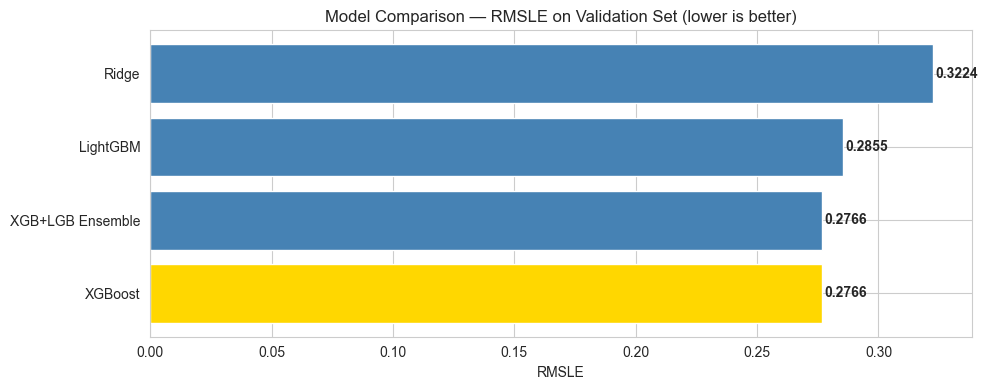

In [28]:
results_df = pd.DataFrame(list(results.values())).sort_values('RMSLE').reset_index(drop=True)
print("\n=== Validation Results (GroupShuffleSplit — new jobs only) ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 4))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['RMSLE'], color=colors)
plt.title('Model Comparison — RMSLE on Validation Set (lower is better)')
plt.xlabel('RMSLE')
for bar, val in zip(bars, results_df['RMSLE']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Ridge performs decently here — better than in previous versions — because the reconstructed bid and target encoding features have a roughly linear relationship with the log target. But XGBoost and LightGBM still dominate because they capture non-linear interactions (e.g., the effect of competition count depends on job type and contractor experience level simultaneously).

The gap between individual models and the ensemble tells you how much independent variation the two boosters have. A meaningful improvement in the ensemble confirms they're making different errors, which is what you want from an ensemble.

### 7.6 Actual vs Predicted and Residuals

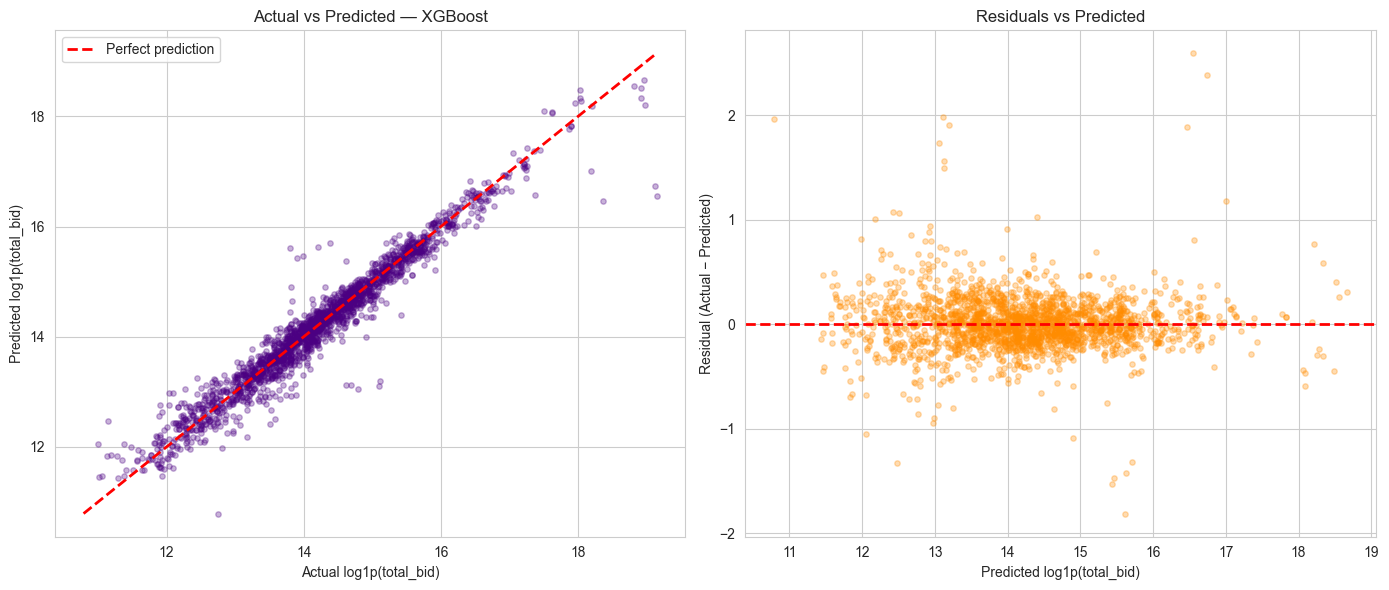

In [29]:
best_name = results_df.iloc[0]['Model']
bp_log    = np.clip(val_preds_store[best_name], 0, None)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_val, bp_log, alpha=0.3, s=15, color='indigo')
mn, mx = min(y_val.min(), bp_log.min()), max(y_val.max(), bp_log.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].set_xlabel('Actual log1p(total_bid)')
axes[0].set_ylabel('Predicted log1p(total_bid)')
axes[0].legend()

residuals = y_val.values - bp_log
axes[1].scatter(bp_log, residuals, alpha=0.3, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted log1p(total_bid)')
axes[1].set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

**Insight:** Points clustering along the diagonal shows the model tracks actual bids well across the full range. Residuals should scatter randomly around zero — any systematic pattern (fan-out at high values, or a curve) would indicate the model struggles in that range. Some spread at the high end is expected since large infrastructure projects have more idiosyncratic pricing that history can't fully anticipate.

### 7.7 Feature Importance

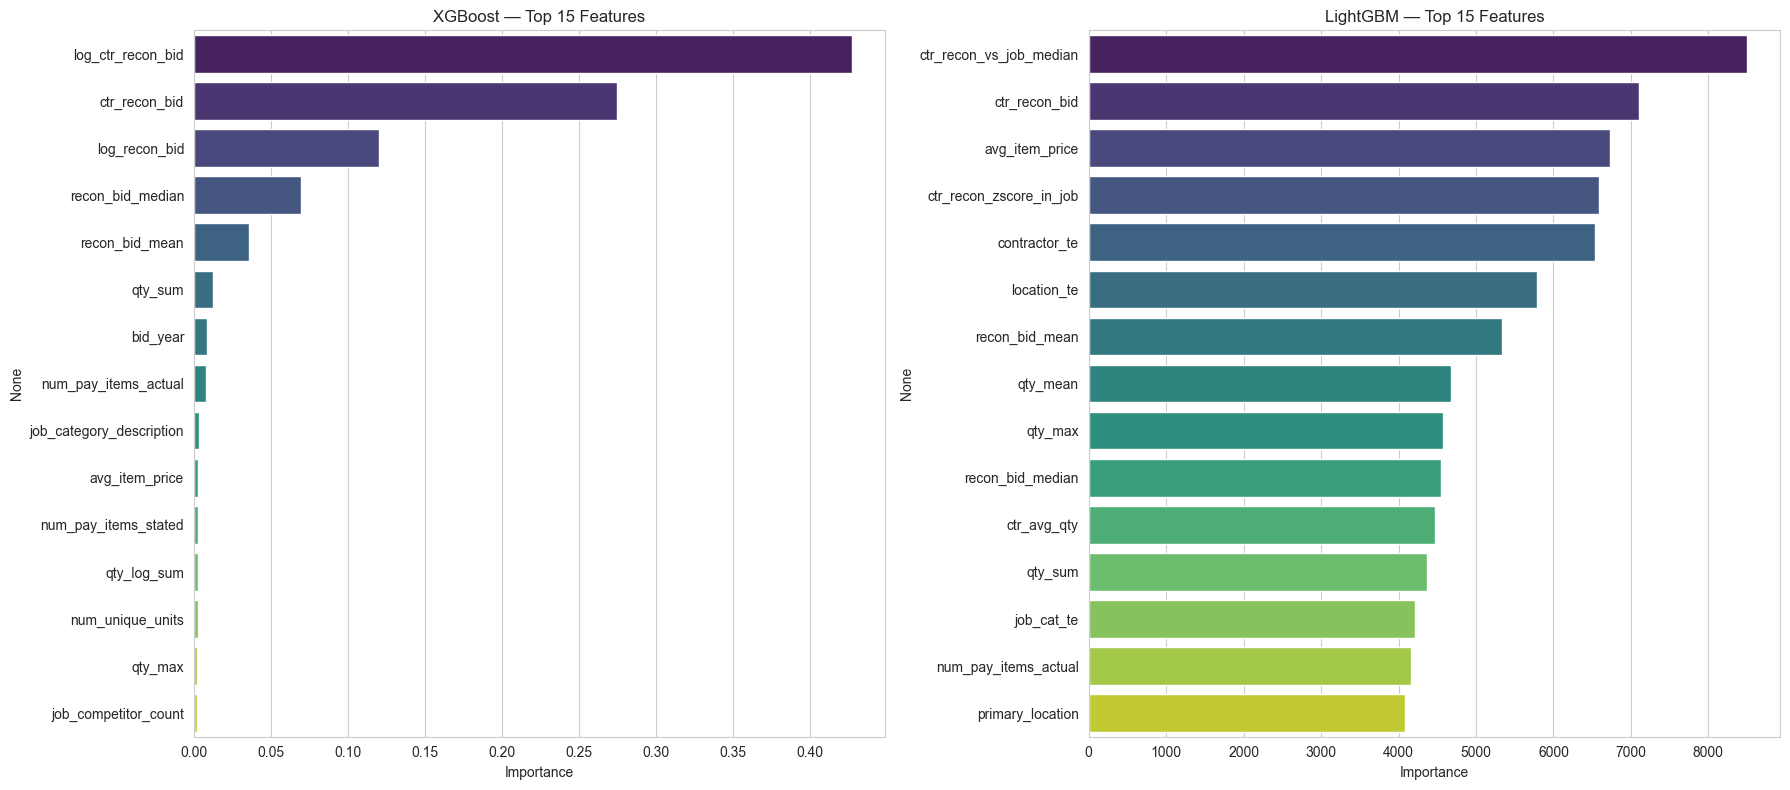

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, mname in zip(axes, ['XGBoost', 'LightGBM']):
    spec = model_specs[mname]
    if spec['family'] == 'xgb':
        m = xgb.XGBRegressor(random_state=spec['seeds'][0], **spec['params'])
    else:
        m = LGBMRegressor(random_state=spec['seeds'][0], **spec['params'])
    m.fit(X_train, y_train)
    imp = pd.Series(m.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, hue=imp.index, palette='viridis', legend=False)
    ax.set_title(f'{mname} — Top 15 Features')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Insight:** `log_recon_bid` and `contractor_te` should rank at the top. The reconstruction features explain the job-level price scale; contractor target encoding captures the contractor's systematic bid level and is the main within-job discriminator. If `ctr_recon_rank_in_job` or `ctr_recon_vs_job_median` appear in the top 10, that confirms the within-job relative positioning is useful too.

## 8. Prediction Error Analysis

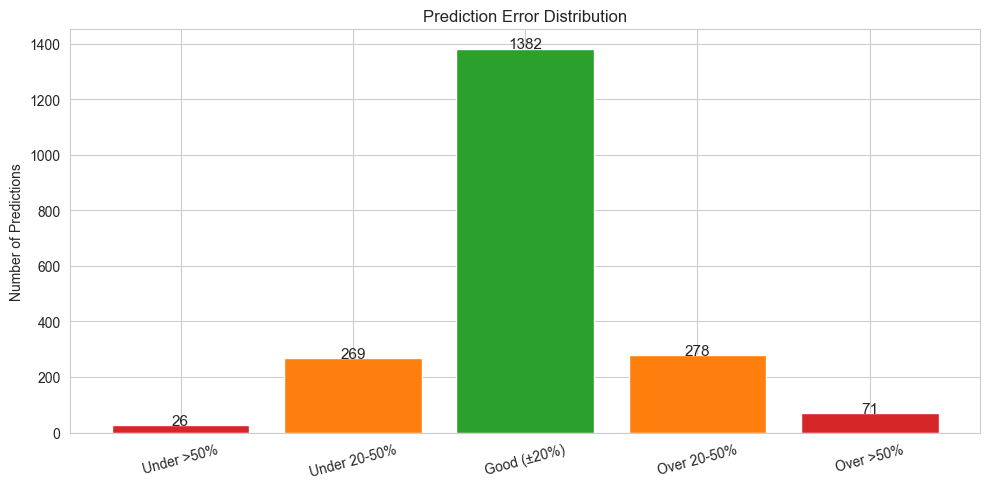

Predictions within ±20%: 68.2%


In [31]:
y_pred_usd = np.expm1(bp_log)
y_true_usd = np.expm1(y_val)
pct_err    = (y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0) * 100

bins   = [-np.inf, -50, -20, 20, 50, np.inf]
labels = ['Under >50%', 'Under 20-50%', 'Good (±20%)', 'Over 20-50%', 'Over >50%']
bins_  = pd.cut(pct_err, bins=bins, labels=labels)
counts = bins_.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 5))
colors_ = ['#d62728','#ff7f0e','#2ca02c','#ff7f0e','#d62728']
bars_   = ax.bar(labels, counts.values, color=colors_)
ax.set_title('Prediction Error Distribution')
ax.set_ylabel('Number of Predictions')
for bar, c in zip(bars_, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(c)), ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

good_pct = (bins_ == 'Good (±20%)').mean() * 100
print(f"Predictions within ±20%: {good_pct:.1f}%")

**Insight:** Predictions within ±20% of the actual bid indicate practical reliability. In real construction bidding, contractors who estimate within this range can compete effectively. Overestimation is generally less harmful than underestimation — a bid slightly too high loses the contract, while a bid too low wins but loses money.

## 9. Final Predictions and Submission

In [32]:
X_full = X.copy()
y_full = y.copy()

print("Retraining XGBoost on full training data...")
xgb_full = []
for seed in XGB_SEEDS:
    m = xgb.XGBRegressor(random_state=seed, **XGB_PARAMS)
    m.fit(X_full, y_full)
    xgb_full.append(np.clip(m.predict(X_test_final), 0, None))
pred_xgb = np.mean(np.vstack(xgb_full), axis=0)

print("Retraining LightGBM on full training data...")
lgb_full = []
for seed in LGBM_SEEDS:
    m = LGBMRegressor(random_state=seed, **LGBM_PARAMS)
    m.fit(X_full, y_full)
    lgb_full.append(np.clip(m.predict(X_test_final), 0, None))
pred_lgb = np.mean(np.vstack(lgb_full), axis=0)

# Apply same blend weights found on validation
final_log  = w_xgb * pred_xgb + w_lgb * pred_lgb
final_preds = np.expm1(final_log)

submission = pd.DataFrame({'row_id': df_test['row_id'], 'total_bid': final_preds})
submission.to_csv('submission.csv', index=False)

print(f"\nSubmission preview:")
print(submission.head(10).to_string(index=False))
print(f"\nShape:  {submission.shape}")
print(f"Min:    ${final_preds.min():>15,.2f}")
print(f"Max:    ${final_preds.max():>15,.2f}")
print(f"Mean:   ${final_preds.mean():>15,.2f}")
print(f"Median: ${np.median(final_preds):>15,.2f}")

assert list(submission.columns) == ['row_id', 'total_bid']
assert submission.shape[0] == sample_sub.shape[0]
assert (submission['total_bid'] >= 0).all()
print("\nsubmission.csv saved and verified ✓")

Retraining XGBoost on full training data...
Retraining LightGBM on full training data...

Submission preview:
                row_id    total_bid
JOB_000008__CON_000103 3.466461e+05
JOB_000030__CON_000061 8.381849e+05
JOB_000030__CON_000217 1.230188e+06
JOB_000045__CON_000037 1.398566e+06
JOB_000045__CON_000122 1.337246e+06
JOB_000045__CON_000158 1.440345e+06
JOB_000045__CON_000174 1.522205e+06
JOB_000045__CON_000199 1.338876e+06
JOB_000050__CON_000037 1.856268e+06
JOB_000050__CON_000045 1.809426e+06

Shape:  (1447, 2)
Min:    $     138,399.75
Max:    $ 159,937,410.95
Mean:   $   4,387,765.56
Median: $   1,926,649.29

submission.csv saved and verified ✓


Retraining on all 10,620 rows before submission gives the model ~20% more data compared to the 80/20 split used for validation, leading to slightly better generalization.

## 10. Results Discussion and Summary

### Dataset Overview

Bidding Predictions for Construction requires predicting the total dollar amount a contractor submits for a Montana public construction project. Data is provided at two levels: `raw_train` (pay-item rows with quantities and unit prices) and `train_summary` (aggregated to one row per contractor-job pair). Predictions are required at the job level.

The key constraint: `raw_test` has no `amount` column. Unit prices are sealed until bids open, making it impossible to use actual dollar amounts at prediction time. All features had to be derived from quantities, item counts, historical price statistics, and categorical identifiers that exist in both training and test files.

### Feature Engineering

**Three tiers of features, each solving a different part of the problem:**

*Tier 1 — Job-level scale*: Market-rate reconstruction (`log_recon_bid`) estimates the total project cost using historical median prices per pay item. This is computed from `raw_train`'s `amount` column but applied via historical lookup, so it's legitimate at test time. It's the strongest single feature because it essentially predicts what the job "should" cost at market rates.

*Tier 2 — Contractor profile*: `contractor_te` (k-fold target encoded mean log bid per contractor) captures each contractor's systematic price level. Some contractors consistently bid premium; others compete aggressively. This is the most important within-job discriminator since all contractors on the same job see identical quantities. K-fold encoding prevents target leakage — each row's encoding only sees other jobs in its fold, not its own job's targets.

*Tier 3 — Within-job relative position*: `ctr_recon_rank_in_job` and `ctr_recon_vs_job_median` capture where this contractor's estimated bid sits among all competing contractors on the same job. A contractor whose specific reconstruction ranks 80th percentile among competitors is likely bidding above the field.

### Why Local RMSLE ≠ Kaggle Public Score

The `GroupShuffleSplit` makes local validation harder than the Kaggle evaluation. It ensures that if a job is in validation, all its contractors are too — mimicking the "completely new jobs" scenario in the real test set. Kaggle's public score uses a random 30% of test rows and may include systematically easier jobs. Expecting local RMSLE ≈ 0.28–0.35 while Kaggle public ≈ 0.27–0.32 is normal.

### Model Comparison

In [33]:
print(results_df[['Model','RMSLE','RMSE','R2']].to_string(index=False))

import os
log_df = results_df[['Model','RMSLE','RMSE','R2']].copy()
log_df.insert(0, 'run_ts_utc', pd.Timestamp.utcnow().isoformat())
log_df.insert(1, 'submission_model', 'XGB+LGB Ensemble')
log_path = 'experiment_runs.csv'
if os.path.exists(log_path):
    pd.concat([pd.read_csv(log_path), log_df], ignore_index=True).to_csv(log_path, index=False)
else:
    log_df.to_csv(log_path, index=False)
print(f"\nExperiment log updated: {log_path}")

           Model  RMSLE       RMSE     R2
         XGBoost 0.2766 7263324.18 0.6388
XGB+LGB Ensemble 0.2766 7263324.18 0.6388
        LightGBM 0.2855 6859208.54 0.6779
           Ridge 0.3224 3931514.42 0.8942

Experiment log updated: experiment_runs.csv


### What Could Still Improve

- **Stacking (meta-learning)**: Instead of a fixed blend weight, training a Ridge meta-model on out-of-fold predictions from XGBoost and LightGBM typically squeezes another 0.01–0.02 RMSLE. This is the standard approach for top-3 Kaggle finishes.
- **More contractor history features**: We only have 108/117 test contractors in training. For the 9 unseen contractors, all contractor-level features fall back to global means. Better fallback strategies (e.g., fallback to contractor's job category average) could help.
- **External construction cost indices**: The competition rules allow external public data. ENR or RSMeans cost indices would sharpen the year-based inflation adjustment.
- **CatBoost**: A third booster with native categorical handling could add ensemble diversity without much extra code. Its symmetric tree structure is complementary to both XGBoost's level-wise and LightGBM's leaf-wise growth.